<a href="https://colab.research.google.com/github/oxedanda/PML_Assignments/blob/main/assignment_1_regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features # input
y = wine_quality.data.targets # output

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Prepare data (train/test split + scaling)

# Convert DataFrames to NumPy arrays
X = X.values
y = y.values.reshape(-1, 1)

# TRAIN DATASET and (independent) TEST DATASET
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the INPUT features (mean 0, std 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # fit on train, transform train
X_test = scaler.transform(X_test) # transform test with same scaler

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5197, 11)
X_test shape: (1300, 11)
y_train shape: (5197, 1)
y_test shape: (1300, 1)


In [ ]:
# Linear Regression model (mini-batch gradient descent

class LinearRegression:

    def __init__(self, learning_rate=0.01, epochs=200, batch_size=32):
        # HYPERPARAMETERS
        self.learning_rate = learning_rate
        self.epochs = epochs # number of passes over the whole train dataset
        self.batch_size = batch_size # number of examples per batch update

    def initialize_weights(self, n_features):
        # MODEL PARAMETERS: weights and bias
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

    def compute_loss(self, y, y_pred):
        # LOSS FUNCTION: Mean Squared Error (MSE)
        return np.mean((y - y_pred) ** 2)

    def fit(self, X, y):
        # FIT METHOD: trains the MODEL using the TRAIN DATASET (X, y)

        # n_samples = number of training examples
        # n_features = number of input features
        n_samples, n_features = X.shape

        # Initialize MODEL PARAMETERS (weights and bias)
        self.initialize_weights(n_features)
        self.loss_history = []

        # TRAINING LOOP
        for epoch in range(self.epochs):  # Epoch loop
            for i in range(0, n_samples, self.batch_size):  # Batch loop

                # Select a BATCH of training examples
                X_batch = X[i:i+self.batch_size]
                y_batch = y[i:i+self.batch_size]

                # Model prediction (forward pass) for the current BATCH
                y_pred = X_batch @ self.weights + self.bias

                # Gradients of loss w.r.t parameters
                error = y_batch - y_pred
                dw = (-2 / len(y_batch)) * X_batch.T @ (y_batch - y_pred)
                db = (-2 / len(y_batch)) * np.sum(y_batch - y_pred)

                # Parameter update (gradient descent)
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

            # Compute LOSS at the end of each EPOCH
            y_full_pred = X @ self.weights + self.bias
            loss = self.compute_loss(y, y_full_pred)
            self.loss_history.append(loss)

    def predict(self, X):
        # PREDICT method: takes INPUT features and outputs predicted quality
        return X @ self.weights + self.bias

In [ ]:
# Create and train the Linear Regression model

# Create the MODEL with chosen hyperparameters
model = LinearRegression(
    learning_rate=0.01,
    epochs=200,
    batch_size=32
)

# Train the MODEL using the TRAIN DATASET
model.fit(X_train, y_train)

# Print the final training loss
print("Final training loss:", model.loss_history[-1])

Final training loss: 0.5402955384950079


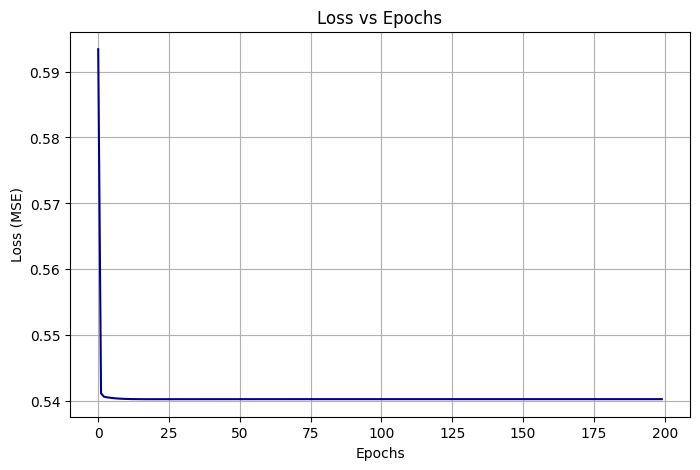

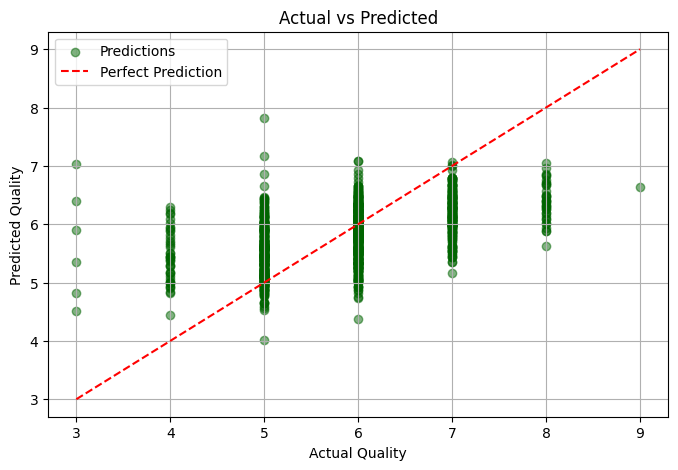

In [ ]:
# Plots: Loss vs Epochs and Actual vs Predicted

# 1️. Loss vs Epochs (training loss per epoch)
plt.figure(figsize=(8,5))
plt.plot(model.loss_history, color='darkblue')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Epochs")
plt.grid(True)
plt.show()

# 2️. Actual vs Predicted on INDEPENDENT TEST DATASET
y_pred = model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkgreen', label='Predictions')
plt.plot([3, 9], [3, 9], color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.legend()
plt.show()